# Mise en contexte du projet

## Contexte du Projet

Ce projet s'inscrit dans le cadre d'une collaboration avec l'Institut National de l'Information Géographique et Forestière (IGN) et concerne l'analyse automatisée des annonces du Bulletin Officiel des Annonces des Marchés Publics (BOAMP).

L'objectif principal est de développer un système de datamining capable d'identifier automatiquement les annonces du BOAMP qui pourraient nécessiter une mise à jour de la base de données vectorielle de l'IGN. Cette base de données est cruciale car elle contient des informations géographiques détaillées du territoire français.

## Enjeux du Projet

- Automatisation du processus de veille : Réduire le temps consacré à la lecture manuelle des annonces du BOAMP
- Précision de la détection : Identifier avec fiabilité les annonces pertinentes pour l'IGN
- Efficacité opérationnelle : Permettre une réaction plus rapide aux modifications potentielles du territoire
- Optimisation des ressources : Concentrer les efforts humains sur les annonces véritablement importantes

La mise en œuvre de ce processus de datamining implique l'utilisation de techniques avancées de traitement du langage naturel (NLP) et d'apprentissage automatique pour analyser et classifier efficacement les annonces du BOAMP.

Nous allons ici, nous intéresser à la variable "cal_réponse_signalement" qui détermine si un BOAMP a été "*Pris en compte*" par l'IGN ou alors "*Rejeté (hors specs)*"


#IMPORTATION DES BIBLIOTHEQUES

In [ ]:
!python -m spacy download fr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 78.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 3.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import spacy
import string
from unidecode import unidecode
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

#IMPORTATION DES DONNEES

In [ ]:
train = pd.read_json("train.jsonl", lines = True)

In [ ]:
test = pd.read_json("test.jsonl", lines = True)

Statistiques descriptives des données TRAIN

In [ ]:
print("Il y a ",train.shape[0]," individus\n")
print("Il y a ", train.shape[1], " variables\n")

print(train.columns, "\n")
print("Nb par classes : ", train.value_counts(train.cal_réponse_signalement))

Il y a  5000  individus

Il y a  28  variables

Index(['OGC_FID', 'boamp_id_annonce', 'boamp_parent_annonce',
       'boamp_theme_boamp', 'boamp_libelle_annonce', 'boamp_statut_annonce',
       'boamp_date_fin_de_marche', 'boamp_num_departement_diffusion',
       'boamp_nom_acheteur', 'boamp_siret_acheteur', 'boamp_type_organisme',
       'boamp_lieu_exec', 'boamp_intitule', 'cal_fichier_pdf',
       'cal_num_signalement', 'cal_theme_signalement',
       'cal_réponse_signalement', 'cal_statut_workflow', 'cal_mot_rang_1',
       'cal_mot_rang_2', 'cal_date_traitement', 'cal_type_localisation',
       'cal_num_departement_exec', 'cal_siren_epci', 'cal_insee_commune_exec',
       'cal_nom_commune_exec', 'cal_adresse_annonce', 'texte_annonce'],
      dtype='object') 

Nb par classes :  cal_réponse_signalement
Pris en compte         3651
Rejete (hors specs)    1349
Name: count, dtype: int64


#NETTOYAGE ET SELECTION DES VARIABLES ET INDIVIDUS

In [ ]:
train['boamp_theme_boamp'].value_counts()

,count
boamp_theme_boamp,
Maîtrise d'oeuvre,679
Bâtiment,307
Voirie,296
Tous corps d'état,233
Voirie et réseaux divers,189
...,...
"Clôture, Espaces verts, Terrassement, Travaux de viabilité, Voirie",1
"Bâtiment, Cloison, faux plafond, Electricité (travaux), Peinture (travaux), Plomberie (travaux)",1
"Etanchéité, Menuiserie, Plomberie (travaux), Peinture (travaux), Gros oeuvre, Signalétique, Audiovisuel, Climatisation",1


In [ ]:
print(train['cal_réponse_signalement'].describe())
train['cal_réponse_signalement'].value_counts()

count               5000
unique                 2
top       Pris en compte
freq                3651
Name: cal_réponse_signalement, dtype: object


,count
cal_réponse_signalement,
Pris en compte,3651
Rejete (hors specs),1349


In [ ]:
# nettoyage
def clean_texte(texte):
  texte = texte.lower() # mise texte en minuscule
  texte = re.sub(r'[^a-zA-Z\s]','',texte) # suppression chiffres et caractères spéciaux
  texte = re.sub(r'\s+',' ',texte).strip() # suppression des espaces inutile
  return texte

#VISUALISATION DES DONNEES SELON NOTRE VARIABLE DE SIGNALEMENT

On choisit les variables à traiter

In [ ]:
NomColgraphe = ['boamp_libelle_annonce', 'boamp_statut_annonce',
       'cal_statut_workflow',
       'cal_type_localisation',
       'cal_num_departement_exec']

On compte le nombre de modalités dans chaque variable

In [ ]:
for var in NomColgraphe:
  print("++++"+var+"++++")
  print("Unique count: " + str(train[var].nunique()))

++++boamp_libelle_annonce++++
Unique count: 4
++++boamp_statut_annonce++++
Unique count: 3
++++cal_statut_workflow++++
Unique count: 1
++++cal_type_localisation++++
Unique count: 19
++++cal_num_departement_exec++++
Unique count: 99


On visualise la distribution de nos données selon notre variable à expliquer

<Figure size 1000x600 with 0 Axes>

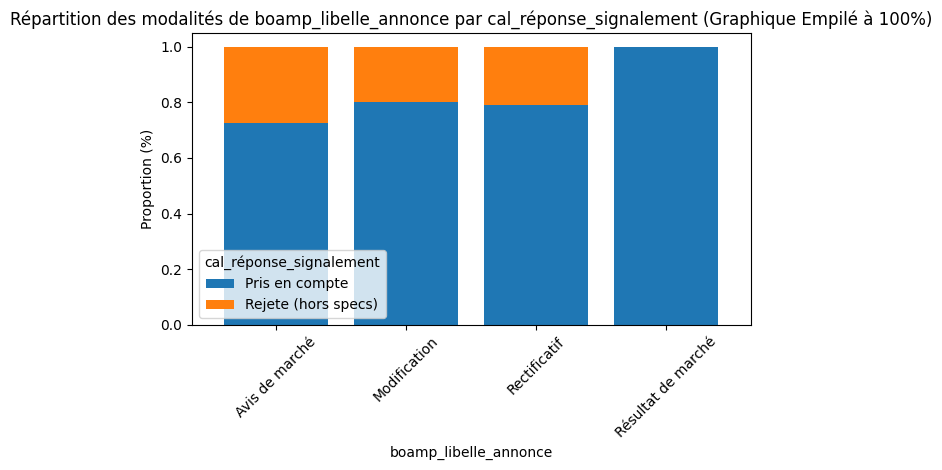

<Figure size 1000x600 with 0 Axes>

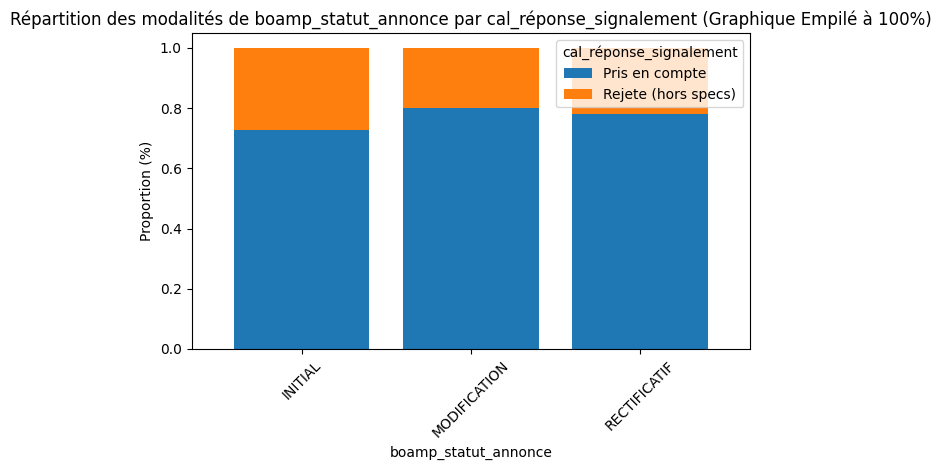

<Figure size 1000x600 with 0 Axes>

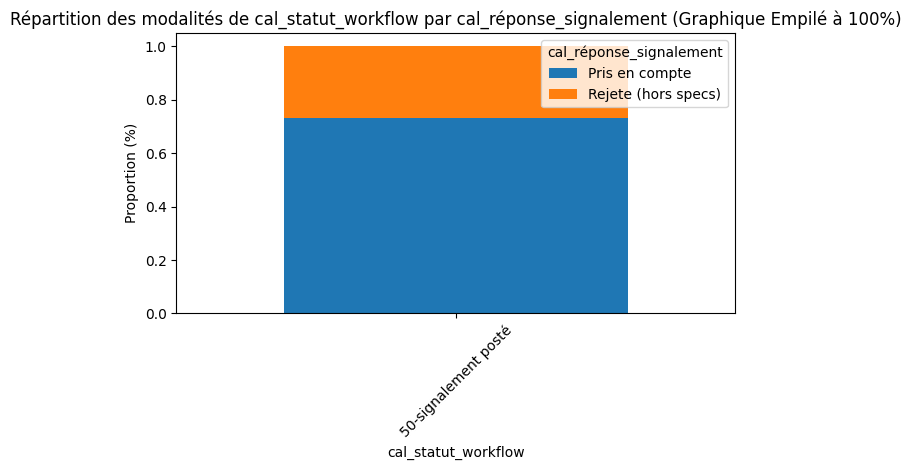

<Figure size 1000x600 with 0 Axes>

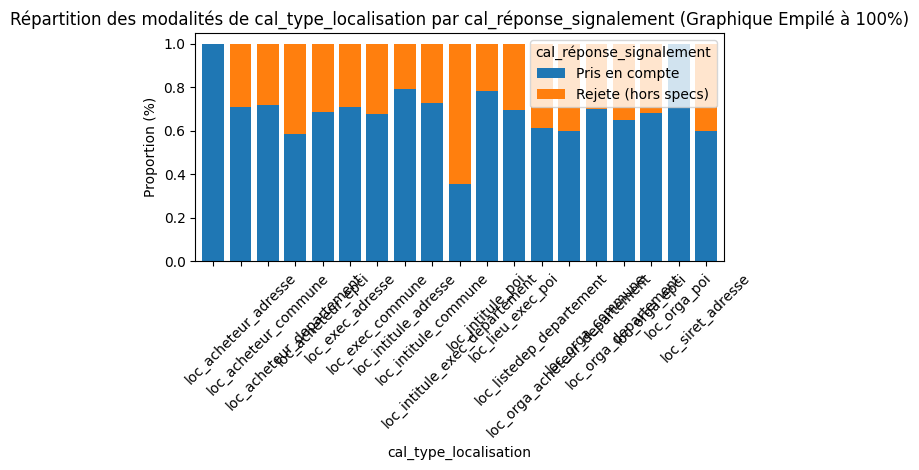

<Figure size 1000x600 with 0 Axes>

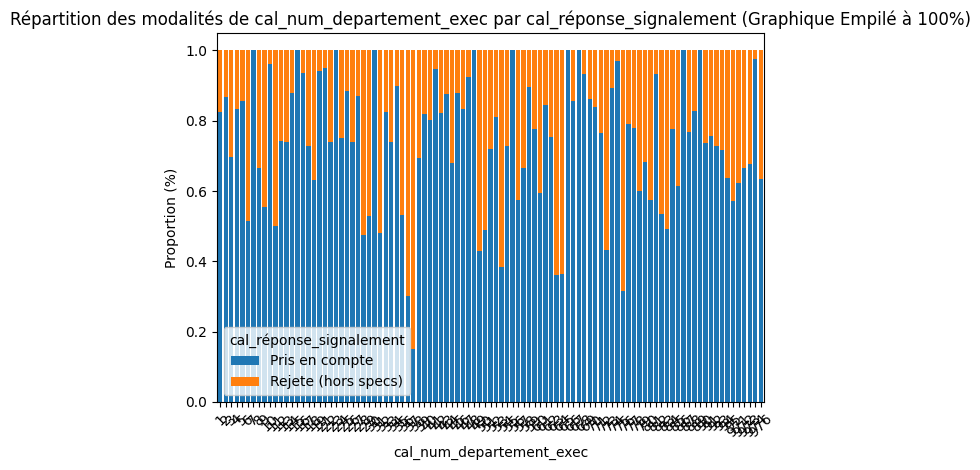

In [ ]:
# Supposons que 'data' soit le DataFrame contenant vos données et 'NomColgraphe' est la liste des noms de colonnes à traiter.
for NomVar in NomColgraphe:
    if NomVar != "cal_réponse_signalement":  # On ne traite pas la variable cal_réponse_signalement
        # Calcul des fréquences relatives pour chaque modalité de la variable 'NomVar'
        # Groupement des données par 'NomVar' et 'cal_réponse_signalement', puis calcul des proportions
        group_data = train.groupby([NomVar, 'cal_réponse_signalement']).size().unstack(fill_value=0)
        group_data = group_data.div(group_data.sum(axis=1), axis=0)  # Normalisation à 100%

        # Création du graphique empilé à 100%
        plt.figure(figsize=(10, 6))
        group_data.plot(kind='bar', stacked=True, width=0.8)

        # Titre et personnalisation
        plt.title(f"Répartition des modalités de {NomVar} par cal_réponse_signalement (Graphique Empilé à 100%)")
        plt.xlabel(NomVar)
        plt.ylabel("Proportion (%)")
        plt.xticks(rotation=45)  # Rotation des labels pour plus de lisibilité
        plt.legend(title="cal_réponse_signalement")
        plt.tight_layout()  # Ajuster la mise en page pour éviter le chevauchement des éléments

        # Affichage du graphique
        plt.show()


#PREPARATION DES DONNEES - LEMATISATION

Dans le cadre de la détection des annonces du BOAMP susceptibles d'entraîner une modification de la base vectorielle de l'IGN, la lemmatisation est particulièrement pertinente pour les raisons suivantes :

- Uniformisation des termes techniques : Les appels d'offres peuvent contenir différentes formes de termes techniques (ex: "cartographique", "cartographiques", "cartographie") qui doivent être traités de manière cohérente
- Réduction du bruit : Les variations grammaticales dans les annonces administratives peuvent créer du bruit dans l'analyse. La lemmatisation permet de standardiser ces variations
- Amélioration de la classification : En réduisant la complexité du vocabulaire, les classifieurs (MultinomialNB, LogisticRegression, etc.) peuvent mieux identifier les patterns pertinents pour la détection des annonces importantes
- Optimisation de la vectorisation : La lemmatisation améliore l'efficacité des méthodes de vectorisation (CountVectorizer, TfidfVectorizer) en réduisant le nombre de caractéristiques uniques à traiter

Cette étape de prétraitement est donc cruciale pour améliorer la qualité de la classification des annonces du BOAMP et identifier plus efficacement celles qui nécessitent une attention particulière de l'IGN.


---



La lemmatisation a été préférée à la racinisation (stemming) pour plusieurs raisons importantes :

- Préservation du sens : La lemmatisation conserve le sens linguistique des mots en les ramenant à leur forme de base (lemme), contrairement à la racinisation qui peut créer des racines non significatives
- Contexte professionnel : Dans un contexte administratif comme le BOAMP, la précision terminologique est cruciale. La lemmatisation permet de maintenir cette précision
- Qualité des résultats : Bien que plus lente que la racinisation, la lemmatisation produit des résultats plus propres et plus cohérents, particulièrement importants pour l'analyse de documents officiels
- Traitement du français : La lemmatisation gère mieux les particularités de la langue française, notamment les variations complexes des verbes et des accords

Bien que la racinisation soit plus rapide en termes de traitement, la nature critique du projet nécessitait la précision et la fiabilité offertes par la lemmatisation.



---


## Lematisation de train

In [ ]:
nlp_fr = spacy.load("fr_core_news_sm")
stop_words = set(stopwords.words("french"))

# lématisation
def lematise_texte(texte):
  doc = nlp_fr(texte)
  lemmatized_text = [token.lemma_ for token in doc]
  return " ".join(lemmatized_text)

train['texte_annonce_lematise'] = train['texte_annonce'].apply(lematise_texte)
train['boamp_intitule_lematise'] = train['boamp_intitule'].apply(lematise_texte)

# Vérification de la lématisation
print(train.at[0,'texte_annonce_lematise'])
print(train.at[0,'boamp_intitule_lematise'])

  avis numéro 23 - 177335 
 
 attention : le information contenu dans le extrait pdf pouvoir dans certain cas ne pas présenter le texte intégral de 
 le annonce . le 
 extrait pdf de annonce de BOAMP ne constituer pas le format officiel , pour consulter le texte intégral 
 au format officiel de présent avis , cliquer sur 
 https://www.boamp.fr/pages/avis/?q=idweb:23-177335 
 
 Département(s ) de publication : 
 31 
 annonce No 
 23 - 177335 
 i. 
 ii . 
 iii . 
 iv . 
 vi . 
 avis de marché 
 Directive 2014/24 / UE 
 le présent avis constituer un appel à le concurrence 
 section i : pouvoir adjudicateur 
 I.1 ) 
 nom et adresse 
 TOULOUSE metropole , numéro national de identification : 24310051800170 , direction de le 
 command public , 6 rue René Leduc , 31505 , Toulouse , f , Courriel : 
 correspondre@aws-france.com 
 , 
 code NUTS : frj23 
 Adresse(s ) internet : 
 adresse principal : 
 https://www.toulouse-metropole.fr/ 
 adresse de profil acheteur : 
 https://www.agysoft.marches-p

Error: need to escape, but no escapechar set

In [ ]:
train.to_json("train_lemmatized.jsonl", orient='records', lines=True, force_ascii=False)
print("Le fichier JSONL 'train_lemmatized.jsonl' a été créé.")

0
(1196, 29)




---

## Lematisation de test

In [ ]:
nlp_fr = spacy.load("fr_core_news_sm")
stop_words = set(stopwords.words("french"))

def lematise_texte(texte):
  doc = nlp_fr(texte)
  lemmatized_text = [token.lemma_ for token in doc if token.text not in stop_words and not token.is_punct]
  return " ".join(lemmatized_text)

test['texte_annonce_lematise'] = test['texte_annonce'].apply(lematise_texte)
test['boamp_intitule_lematise'] = test['boamp_intitule'].apply(lematise_texte)

#Vérifier la lématisation.
print(test.at[0,'texte_annonce_lematise'])
print(test.at[0,'boamp_intitule_lematise'])
print(test['texte_annonce_lematise'].isnull().sum())

  avis numéro 23 161305 
 
 attention information contenu le extrait pdf pouvoir certain cas présenter texte intégral 
 le annonce le 
 extrait pdf annonce BOAMP constituer format officiel consulter texte intégral 
 format officiel présent avis cliquer 
 https://www.boamp.fr/pages/avis/?q=idweb:23-161305 
 
 Département(s publication 
 33 
 annonce No 
 23 161305 
 i. 
 ii 
 iii 
 iv 
 V. 
 vi 
 FNS SIMPLE avis de marché 
 section i identification le acheteur 
 nom complet le acheteur 
 coba 
 type numéro national de indentification 
 siret 
 n degré national de identification 
 24330056300026 
 ville 
 arcachon 
 code postal 
 33311 
 groupement commande 
 non 
 département(s publication 
 33 
 section 2 communication 
 lien direct document consultation 
 https://www.marches-publics.info/mpiaws/index.cfm 
 fuseaction = dematent.login&type = dce&idm=1379812 
 identifiant interne consultation 
 2023 95 
 intégralité document profil de acheteur 
 Oui 
 utilisation moyen communication non

In [ ]:
test.to_json("test_lemmatized.jsonl", orient='records', lines=True, force_ascii=False)
print("Le fichier JSONL 'test_lemmatized.jsonl' a été créé.")

Le fichier JSONL 'test_lemmatized.jsonl' a été créé.
0


#IMPORT DES DONNEES LEMATISEES

Ouverture du json pour éviter de relematiser les données

In [ ]:
train_new = pd.read_json("train_lemmatized.jsonl", lines=True)
test_new = pd.read_json("test_lemmatized.jsonl", lines=True)

# Garde uniquement les colonnes 'texte_annonce_lematise' et 'boamp_intitule'
train_new = train_new[['texte_annonce_lematise', 'boamp_intitule_lematise','cal_réponse_signalement']]
test_new = test_new[['texte_annonce_lematise', 'boamp_intitule_lematise','OGC_FID']]

#VECTORISATION DU TEXTE

##Comptages simples

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import nltk
from sklearn.feature_extraction.text import CountVectorizer


def transform_to_countvectorizer_with_id(df, column_name):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(df[column_name])
    return X, vectorizer

X1, vectorizer1 = transform_to_countvectorizer_with_id(train_new, 'texte_annonce_lematise')
X2, vectorizer2 = transform_to_countvectorizer_with_id(train_new, 'boamp_intitule_lematise')
X_test1, vectorizer_test1 = transform_to_countvectorizer_with_id(test_new, 'texte_annonce_lematise')
X_test2, vectorizer_test2 = transform_to_countvectorizer_with_id(test_new, 'boamp_intitule_lematise')
print(X1.shape)

(5000, 64855)


###Trouver un mot grâce aux comptages

In [ ]:
vectorizer1.get_feature_names_out()[64164]

'weimert'

##Comptages pondérés

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def transform_to_tfidf(df, column_name):
    tfidf_vectorizer = TfidfVectorizer()
    X = tfidf_vectorizer.fit_transform(df[column_name])
    return X, tfidf_vectorizer

tfidf_matrix, tfidf_vectorizer = transform_to_tfidf(train_new, 'texte_annonce_lematise')
tfidf_matrix2, tfidf_vectorizer2 = transform_to_tfidf(train_new, 'boamp_intitule_lematise')
tfidf_test_matrix, tfidf_vectorizer = transform_to_tfidf(test_new, 'texte_annonce_lematise')
tfidf_test_matrix2, tfidf_vectorizer2 = transform_to_tfidf(test_new, 'boamp_intitule_lematise')

###Trouver un mot grâce suite aux comptages

In [ ]:
tfidf_vectorizer.get_feature_names_out()[34287]

IndexError: index 34287 is out of bounds for axis 0 with size 23609

#REDUCTION DE DIMENSIONS

Décomposition tronquées en valeurs singulières (meilleur dimension comptage simple : 500, pondérées : 1500)

## Recherche des meilleurs dimensions a prendre selon le type de comptage (simple ou pondéré)

ValueError: x and y must have same first dimension, but have shapes (60,) and (4,)

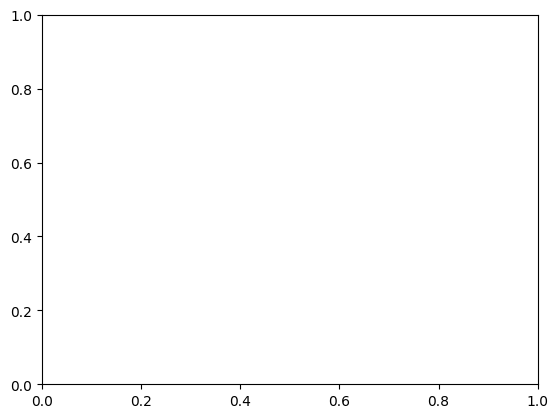

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import joblib  # Pour mettre en cache si nécessaire

# Concaténer les deux matrices sparse si vous travaillez avec X1 et X2
X_combined = hstack([tfidf_matrix, tfidf_matrix2])
y = train_new['cal_réponse_signalement']

# Initialisation de la liste pour stocker les F1-Scores
f1_scores = []

# Scorer personnalisé pour le F1-Score Kaggle
f1_scorer = make_scorer(f1_score, pos_label="Pris en compte", average="weighted")

# Utilisation de la parallélisation pour accélérer la validation croisée
# Remarque : Si vous avez trop de cœurs, il est préférable de ne pas trop les solliciter.
n_jobs = -1  # -1 utilise tous les cœurs disponibles, vous pouvez ajuster ce paramètre

liste = [1000,1250,1500,1700]
# Réduction de dimension et évaluation avec F1-Score pondéré
for n_components in liste:
    # Application de SVD avec un nombre donné de composants
    svd = TruncatedSVD(n_components=n_components, random_state=42)  # Graine pour reproductibilité
    X_svd = svd.fit_transform(X_combined)  # Appliquer SVD

    # Initialisation du modèle de régression logistique
    clf = LogisticRegression(max_iter=1000, n_jobs=n_jobs)

    # Validation croisée avec le scorer F1-Score personnalisé
    score = cross_val_score(clf, X_svd, y, cv=5, scoring=f1_scorer, n_jobs=n_jobs)
    f1_scores.append(score.mean())

Etant donnée que la recherche de la dimension idéale est longue, nous exportons nos résultats via csv afin de ne pas regénérer ou perdre nos résultats

In [ ]:
# Générer les valeurs de "Nb_composant" (de 10 à 600, pas de 10)
nb_composant = liste

# Créer un DataFrame avec les colonnes
df = pd.DataFrame({
    'Nb_composant': nb_composant,
    'Valeur': f1_scores
})

# Sauvegarder le DataFrame en fichier CSV
df.to_csv('resultats4.csv', index=False, encoding='utf-8')

print("CSV créé avec succès !")

CSV créé avec succès !


### Visualisation des meilleurs dimensions

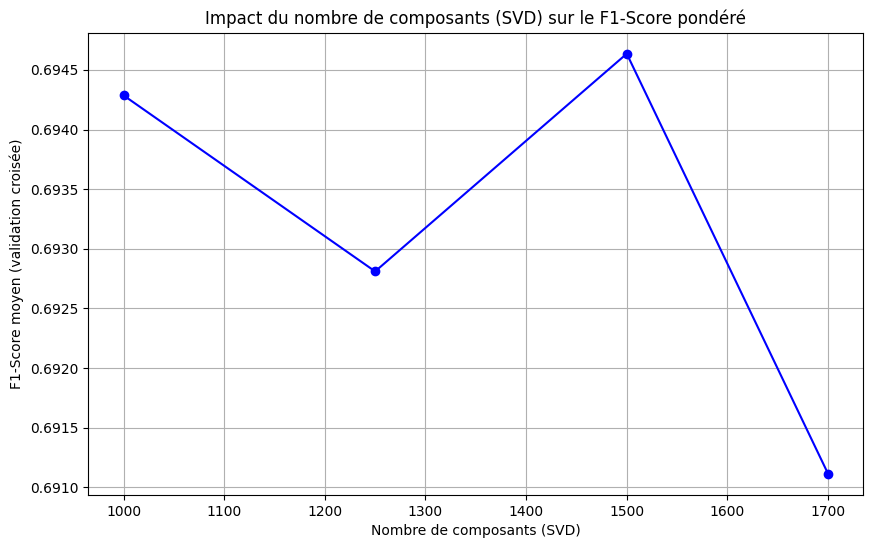


Le nombre optimal de composants basé sur le F1-Score est : 1500


In [ ]:
df1_scores = pd.read_csv("resultats4.csv")

f1_scores = df1_scores['Valeur']
nb_composant = df1_scores['Nb_composant']

# Tracer les F1-scores en fonction du nombre de composants
plt.figure(figsize=(10, 6))
plt.plot(nb_composant, f1_scores, marker='o', linestyle='-', color='b')
plt.xlabel('Nombre de composants (SVD)')
plt.ylabel('F1-Score moyen (validation croisée)')
plt.title('Impact du nombre de composants (SVD) sur le F1-Score pondéré')
plt.grid()
plt.show()

# Trouver le nombre optimal de composants basé sur le F1-Score
optimal_components = nb_composant[f1_scores.idxmax()]  # Utilise idxmax() pour trouver l'indice du max F1-score
print(f"\nLe nombre optimal de composants basé sur le F1-Score est : {optimal_components}")

## Décomposition tronquées en valeurs singulières - Réduction de dimension de notre jeu de données avec les dimensions les plus optimales

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack

def transform_to_tfidf(df, column_name, tfidf_vectorizer=None):
    # Si un vectorizer est fourni, on l'utilise pour transformer les données
    if tfidf_vectorizer:
        X = tfidf_vectorizer.transform(df[column_name])
    else:
        tfidf_vectorizer = TfidfVectorizer()
        X = tfidf_vectorizer.fit_transform(df[column_name])
    return X, tfidf_vectorizer

# Transformation pour l'ensemble d'entraînement
tfidf_matrix, tfidf_vectorizer = transform_to_tfidf(train_new, 'texte_annonce_lematise')
tfidf_matrix2, tfidf_vectorizer2 = transform_to_tfidf(train_new, 'boamp_intitule_lematise')

# Transformation pour l'ensemble de test en utilisant le vectorizer entraîné
tfidf_test_matrix, _ = transform_to_tfidf(test_new, 'texte_annonce_lematise', tfidf_vectorizer)
tfidf_test_matrix2, _ = transform_to_tfidf(test_new, 'boamp_intitule_lematise', tfidf_vectorizer2)

# Combinaison des matrices d'entraînement et de test
X_combined = hstack([tfidf_matrix, tfidf_matrix2])  # Matrices d'entraînement
X_test_combined = hstack([tfidf_test_matrix, tfidf_test_matrix2])  # Matrices de test

# Vérification des dimensions
print(f"Shape of X_combined (train): {X_combined.shape}")
print(f"Shape of X_test_combined (test): {X_test_combined.shape}")

# Création du modèle TruncatedSVD
svd = TruncatedSVD(n_components=1500)

# Appliquez SVD uniquement sur les données d'entraînement
X_svd = svd.fit_transform(X_combined)

# Tr  ansformez les données de test en utilisant le modèle appris sur les données d'entraînement
X_test_svd = svd.transform(X_test_combined)

# Affichage des résultats après la réduction de dimension
print(f"Shape of X_svd (train): {X_svd.shape}")
print(f"Shape of X_test_svd (test): {X_test_svd.shape}")

Shape of X_combined (train): (5000, 73754)
Shape of X_test_combined (test): (1196, 73754)
Shape of X_svd (train): (5000, 1500)
Shape of X_test_svd (test): (1196, 1500)


## Factorisation en matrices non négatives (NMF)

### Recherche des dimensions les plus optmiales

In [ ]:
from sklearn.decomposition import NMF
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer
from scipy.sparse import hstack
import matplotlib.pyplot as plt

# Concaténer les deux matrices sparse si vous travaillez avec X1 et X2
X_combined = hstack([tfidf_matrix, tfidf_matrix2])  # Assurez-vous que tfidf_matrix et tfidf_matrix2 sont définis
y = train_new['cal_réponse_signalement']  # Définir la variable cible

# Initialisation de la liste pour stocker les F1-Scores
f1_scores = []

# Scorer personnalisé pour le F1-Score
f1_scorer = make_scorer(f1_score, pos_label="Pris en compte", average="weighted")

# Utilisation de la parallélisation pour accélérer la validation croisée
n_jobs = -1  # -1 utilise tous les cœurs disponibles

# Liste des nombres de composants NMF à tester
liste = [100, 250, 500, 1000, 1500]

# Réduction de dimension et évaluation avec F1-Score pondéré
for n_components in liste:
    # Application de NMF avec un nombre donné de composants
    nmf = NMF(n_components=n_components, init='random', random_state=42)  # NMF avec nombre de composants
    X_nmf = nmf.fit_transform(X_combined)  # Appliquer NMF

    # Initialisation du modèle de régression logistique
    clf = LogisticRegression(max_iter=1000, n_jobs=n_jobs)

    # Validation croisée avec le scorer F1-Score personnalisé
    score = cross_val_score(clf, X_nmf, y, cv=5, scoring=f1_scorer, n_jobs=n_jobs)
    f1_scores.append(score.mean())

    # Affichage de l'évolution du F1-Score pour chaque nombre de composants
    print(f"F1-Score pour {n_components} composants: {score.mean():.4f}")

# Visualisation des résultats
plt.plot(liste, f1_scores, marker='o', linestyle='-', color='b')
plt.xlabel('Nombre de composants')
plt.ylabel('F1-Score (Pondéré)')
plt.title('Évaluation de NMF avec différents nombres de composants')
plt.show()

### Réduction de dimension de notre jeu de données avec les dimensions les plus optimales

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import pandas as pd
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

# Charger les stopwords français
stop_words_french = stopwords.words('french')

# Créer le vectoriseur avec les stopwords français
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words=stop_words_french)

# Transformer les données
X_tfidf = tfidf_vectorizer.fit_transform(train_new['texte_annonce_lematise'])


# Appliquer NMF pour la réduction de dimension
nmf = NMF(n_components=100, init='random', random_state=42)
X_nmf = nmf.fit_transform(X_tfidf)

# Afficher la matrice réduite
print("Matrice après NMF :")
print(X_nmf)

vectorizer = CountVectorizer()
# Afficher les composants (top mots pour chaque composant)
feature_names = tfidf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(nmf.components_):
    print(f"\nTop words for topic #{topic_idx}:")
    print([feature_names[i] for i in topic.argsort()[:-6 - 1:-1]])  # Affiche les 5 meilleurs mots


CalledProcessError: Command '['/usr/bin/python3', '-m', 'pip', 'install', 'newspaper']' returned non-zero exit status 1.

#Construire des variables additionnelles

##Longueur du texte : La longueur d'une annonce pourrait être un bon indicateur de sa pertinence.

In [ ]:
# Fonction pour calculer la longueur du texte
def calculer_longueur(texte):
    if isinstance(texte, str):
        return len(texte.split())  # Nombre de mots
    return 0

# Appliquer la fonction à la colonne 'boamp_theme_boamp'
train_new['longueur_texte'] = train_new['boamp_intitule_lematise'].apply(calculer_longueur)

# Vérification
print("Statistiques sur la variable 'longueur_texte' :")
print(train_new['longueur_texte'].describe())

In [ ]:
# Fonction pour calculer la longueur du texte
def calculer_longueur(texte):
    if isinstance(texte, str):
        return len(texte.split())  # Nombre de mots
    return 0

# Appliquer la fonction à la colonne 'boamp_theme_boamp'
train_new['longueur_texte'] = train_new['texte_annonce_lematise'].apply(calculer_longueur)

# Vérification
print("Statistiques sur la variable 'longueur_texte' :")
print(train_new['longueur_texte'].describe())

##Fréquence des classes grammaticales : Vous pourriez analyser la structure du texte pour en extraire des informations sur la syntaxe.

In [ ]:
import spacy

# Charger le modèle spaCy pour la langue française
nlp = spacy.load("fr_core_news_sm")

# Fonction pour compter les classes grammaticales
def frequence_classes_grammaticales(texte):
    pos_counts = {'NOUN': 0, 'VERB': 0, 'ADJ': 0, 'ADV': 0}
    if isinstance(texte, str):
        doc = nlp(texte)
        for token in doc:
            if token.pos_ in pos_counts:
                pos_counts[token.pos_] += 1
    return pos_counts

# Appliquer la fonction à chaque texte
classes_grammaticales = train_new['boamp_intitule_lematise'].apply(frequence_classes_grammaticales)

# Convertir les résultats en DataFrame
classes_df = pd.DataFrame(list(classes_grammaticales))

# Fusionner les fréquences dans le DataFrame principal
train = pd.concat([train_new, classes_df], axis=1)

# Vérification
print("Exemple des fréquences des classes grammaticales :")
print(train_new[['NOUN', 'VERB', 'ADJ', 'ADV']].head())

In [ ]:
import spacy

# Charger le modèle spaCy pour la langue française
nlp = spacy.load("fr_core_news_sm")

# Fonction pour compter les classes grammaticales
def frequence_classes_grammaticales(texte):
    pos_counts = {'NOUN': 0, 'VERB': 0, 'ADJ': 0, 'ADV': 0}
    if isinstance(texte, str):
        doc = nlp(texte)
        for token in doc:
            if token.pos_ in pos_counts:
                pos_counts[token.pos_] += 1
    return pos_counts

# Appliquer la fonction à chaque texte
classes_grammaticales = train_new['texte_annonce_lematise'].apply(frequence_classes_grammaticales)

# Convertir les résultats en DataFrame
classes_df = pd.DataFrame(list(classes_grammaticales))

# Fusionner les fréquences dans le DataFrame principal
train = pd.concat([train_new, classes_df], axis=1)

# Vérification
print("Exemple des fréquences des classes grammaticales :")
print(train_new[['NOUN', 'VERB', 'ADJ', 'ADV']].head())

##Présence d'URLs

In [ ]:
import re

# Fonction pour détecter la présence d'URLs
def presence_url(texte):
    if isinstance(texte, str):
        return bool(re.search(r'https?://\S+', texte))
    return False

# Appliquer la fonction à la colonne 'boamp_theme_boamp'
train_new['presence_url'] = train_new['boamp_intitule_lematise'].apply(presence_url)

# Vérification
print("Nombre de textes avec URLs :", train['presence_url'].sum())

In [ ]:
import re

# Fonction pour détecter la présence d'URLs
def presence_url(texte):
    if isinstance(texte, str):
        return bool(re.search(r'https?://\S+', texte))
    return False

# Appliquer la fonction à la colonne 'boamp_theme_boamp'
train_new['presence_url'] = train_new['texte_annonce_lematise'].apply(presence_url)

# Vérification
print("Nombre de textes avec URLs :", train_new['presence_url'].sum())

##Nombre de nombres dans le texte

In [ ]:
# Fonction pour compter les nombres dans le texte
def compter_nombres(texte):
    if isinstance(texte, str):
        return len(re.findall(r'\d+', texte))
    return 0

# Appliquer la fonction à la colonne 'boamp_theme_boamp'
train_new['nombre_nombres'] = train_new['boamp_intitule_lematise'].apply(compter_nombres)

# Vérification
print("Statistiques sur la variable 'nombre_nombres' :")
print(train_new['nombre_nombres'].describe())

In [ ]:
# Fonction pour compter les nombres dans le texte
def compter_nombres(texte):
    if isinstance(texte, str):
        return len(re.findall(r'\d+', texte))
    return 0

# Appliquer la fonction à la colonne 'boamp_theme_boamp'
train_new['nombre_nombres'] = train_new['texte_annonce_lematise'].apply(compter_nombres)

# Vérification
print("Statistiques sur la variable 'nombre_nombres' :")
print(train_new['nombre_nombres'].describe())

#CLASSIFICATION

## Objectif de la Classification dans le Contexte du BOAMP

La classification est essentielle dans ce projet pour plusieurs raisons fondamentales :

- Automatisation du tri : Face au volume important d'annonces publiées quotidiennement sur le BOAMP, la classification permet d'identifier automatiquement les annonces pertinentes pour l'IGN
- Réduction de la charge de travail : Sans classification automatique, l'analyse manuelle de chaque annonce serait chronophage et inefficace
- Priorisation des actions : La classification aide à identifier rapidement les annonces qui nécessitent une intervention ou une mise à jour de la base vectorielle de l'IGN
- Standardisation du processus : L'utilisation d'algorithmes de classification garantit une cohérence dans l'évaluation des annonces, réduisant les biais humains

En utilisant des techniques de classification supervisée, nous pouvons développer un système capable d'apprendre à partir d'exemples annotés pour identifier automatiquement les annonces pertinentes pour l'IGN, optimisant ainsi le processus de veille et de mise à jour des données géographiques.

##CLASSIFIEUR BAYESIEN NAÏF

Etant donnée que le classifieur multinomial ne marche pas sur les données négatives, nous choisisons d'effectuer notre classifieur sur les données réduites à l'aide de la technique NMF (Facteur en Matrice Non négative)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score, accuracy_score

# Définir la variable cible (y)
y = train_new['cal_réponse_signalement']  # Remplace par le nom de ta variable cible

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_nmf, y, test_size=0.2, random_state=42)

# Initialiser le classifieur bayésien naïf
nb_classifier = MultinomialNB()

# Entraîner le classifieur
nb_classifier.fit(X_train, y_train)

# Faire des prédictions sur l'ensemble de test
y_pred = nb_classifier.predict(X_test)

# Évaluer les performances du modèle
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")  # Ajuster 'average' selon tes besoins

# Afficher les résultats
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7410
F1-Score (Weighted): 0.6308

Classification Report:
                      precision    recall  f1-score   support

     Pris en compte       0.74      1.00      0.85       741
Rejete (hors specs)       0.00      0.00      0.00       259

           accuracy                           0.74      1000
          macro avg       0.37      0.50      0.43      1000
       weighted avg       0.55      0.74      0.63      1000



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Prédiction des classes avec le classifieur Multinomial et extraction en csv du résultat

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import nltk

# Étape 1 : Charger les données
# Assurez-vous que train_new et test_new sont déjà chargés

# Étape 2 : Télécharger les stopwords en français
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words_french = stopwords.words('french')

# Étape 3 : Vectorisation des données avec TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words=stop_words_french)
X_train_tfidf = tfidf_vectorizer.fit_transform(train_new['texte_annonce_lematise'])  # Jeu d'entraînement
X_test_tfidf = tfidf_vectorizer.transform(test_new['texte_annonce_lematise'])        # Jeu de test

# Étape 4 : Préparer la variable cible
y_train = train_new['cal_réponse_signalement']  # Variable cible pour l'entraînement

# Étape 5 : Initialiser et entraîner le modèle Bayésien naïf
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)

# Étape 6 : Prédictions sur le jeu de test
y_pred_test = nb_classifier.predict(X_test_tfidf)

# Étape 7 : Préparer un DataFrame pour l'export
results = pd.DataFrame({
    'OGC_FID': test_new['OGC_FID'],  # Colonne identifiant unique dans le jeu de test
    'cal_réponse_signalement': y_pred_test  # Prédictions
})

# Étape 8 : Exporter les résultats dans un fichier CSV
results.to_csv('soumission_naive_bayes.csv', index=False)
print("Fichier CSV 'soumission_naive_bayes.csv' créé avec succès !")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Fichier CSV 'soumission_naive_bayes.csv' créé avec succès !


##REGRESSION LOGISTIQUES

Détermition des hyperparamètres les plus optimaux pour notre régression logistique

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Fonction pour effectuer un GridSearch avec régression logistique
def logistic_regression_grid_search(X, y, param_grid=None):
    """
    Effectue un GridSearchCV pour la régression logistique avec différents types de régularisation.
    Affiche les résultats textuellement en utilisant le F1-Score pondéré.
    """
    # Paramètres par défaut pour la régression logistique si aucun param_grid n'est passé
    if param_grid is None:
        param_grid = {
            'penalty': ['l1', 'l2'],  # Tester à la fois L1 et L2 pour la régularisation
            'solver': ['saga'],  # 'saga' supporte L1, L2, ElasticNet
            'C': [1,1.5,2,4],  # 6 valeurs de C
            'max_iter': [5000]  # Nombre d'itérations pour la convergence
        }

    # Initialisation du modèle de régression logistique
    log_reg = LogisticRegression()

    # GridSearchCV pour trouver les meilleurs paramètres avec le F1-Score pondéré comme critère
    grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='f1_weighted')
    grid_search.fit(X, y)

    # Résultats de GridSearch
    print(f"Meilleurs paramètres: {grid_search.best_params_}")
    print(f"Meilleur F1-Score pondéré (validation croisée) : {grid_search.best_score_:.4f}")

    # Résumé des résultats
    results = grid_search.cv_results_

    print("\nRésumé des performances par type de régularisation et valeur de C (F1-Score pondéré) :")
    for penalty in ['l1', 'l2']:  # Enlève 'none' et 'elasticnet' car ces valeurs n'ont pas été testées
        print(f"\nRégularisation: {penalty}")
        for idx, (C, mean_score) in enumerate(zip(results['param_C'], results['mean_test_score'])):
            if results['param_penalty'][idx] == penalty:
                print(f"  C = {C}: F1-Score pondéré moyen = {mean_score:.4f}")

    return grid_search.best_params_, grid_search.best_score_

# Exemple d'appel de la fonction avec X (features) et y (target)
# Remplacer X_svd et train_new['cal_réponse_signalement'] par vos données spécifiques
best_params, best_score = logistic_regression_grid_search(X_svd, train_new['cal_réponse_signalement'])

Meilleurs paramètres: {'C': 4, 'max_iter': 5000, 'penalty': 'l2', 'solver': 'saga'}
Meilleur F1-Score pondéré (validation croisée) : 0.7299

Résumé des performances par type de régularisation et valeur de C (F1-Score pondéré) :

Régularisation: l1
  C = 1.0: F1-Score pondéré moyen = 0.7055
  C = 1.5: F1-Score pondéré moyen = 0.7253
  C = 2.0: F1-Score pondéré moyen = 0.7296
  C = 4.0: F1-Score pondéré moyen = 0.7292

Régularisation: l2
  C = 1.0: F1-Score pondéré moyen = 0.6910
  C = 1.5: F1-Score pondéré moyen = 0.7103
  C = 2.0: F1-Score pondéré moyen = 0.7201
  C = 4.0: F1-Score pondéré moyen = 0.7299


Prédiction des classes avec le classifieur Multinomial et extraction en csv du résultat

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression()
param_grid = {
            'penalty': ['l2'],  # Types de régularisation
            'solver': ['saga'],  # 'saga' supporte L1, L2, ElasticNet
            'C': [4],  # Valeurs pour le paramètre C (régularisation)
            'max_iter': [5000]  # Nombre d'itérations pour la convergence
        }

# GridSearchCV pour trouver les meilleurs paramètres avec F1-score pondéré comme critère
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='f1_weighted')

# Entraîner le modèle KNN avec les données transformées par SVD
grid_search.fit(X_svd, train_new['cal_réponse_signalement'])

# Prédire les résultats sur le jeu de test
y_pred = grid_search.predict(X_test_svd)

# Créer un DataFrame avec la colonne 'OGC_FID' de test_new et les prédictions
test_results = pd.DataFrame({
    'OGC_FID': test_new['OGC_FID'],  # Utiliser la colonne OGC_FID du jeu de données test
    'cal_réponse_signalement': y_pred
})

# Créer un DataFrame avec la colonne 'OGC_FID' de test_new et les prédictions
test_results = pd.DataFrame({
    'OGC_FID': test_new['OGC_FID'],  # Utiliser la colonne OGC_FID du jeu de données test
    'cal_réponse_signalement': y_pred
})

# Sauvegarder le DataFrame dans un fichier CSV sans l'index et avec un séparateur virgule
test_results.to_csv("soumission_kaagle.csv", index=False, sep=',')  # index=False pour enlever les row names

print("Le fichier csv a été généré sans index et avec séparateur virgule")

Le fichier csv a été généré sans index et avec séparateur virgule


##METHODES DES K PLUS PROCHES VOISINS

Détermition du meilleur modèle avec les hyperparamètres les plus optimaux

Répartition des classes dans 'cal_réponse_signalement' :
cal_réponse_signalement
Pris en compte         3651
Rejete (hors specs)    1349
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_response.py", line 214, in _get_response_values
    y_pred = prediction_method


Meilleurs paramètres: {'metric': 'minkowski', 'n_neighbors': 14, 'weights': 'distance'}
Meilleure Accuracy (validation croisée) : 0.7362


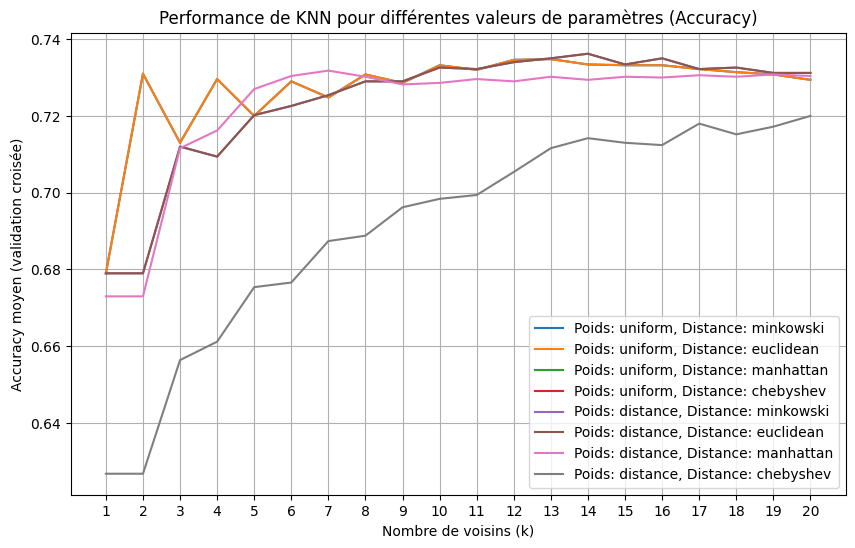


Comptage des prédictions :
Pris en compte         3651
Rejete (hors specs)    1349
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

def knn_grid_search(X, y, param_grid=None):
    """
    Fonction qui effectue un GridSearchCV pour la méthode des k plus proches voisins (KNN),
    afin de trouver les meilleurs paramètres et de générer un graphique des performances en utilisant l'Accuracy.

    Paramètres:
    - X : Matrice des caractéristiques (features)
    - y : Variable cible à prédire
    - param_grid : Dictionnaire des paramètres à tester dans le GridSearch (par défaut, test des voisins, des poids et des distances)

    Retourne les meilleurs paramètres et génère un graphique des performances.
    """
    # Affichage de la répartition des classes dans y
    print("Répartition des classes dans 'cal_réponse_signalement' :")
    print(y.value_counts())

    if param_grid is None:
        # Paramètres par défaut pour KNN
        param_grid = {
            'n_neighbors': range(1, 21),  # Teste des valeurs pour k de 1 à 20
            'weights': ['uniform', 'distance'],  # Teste différentes stratégies de poids
            'metric': ['minkowski', 'euclidean', 'manhattan', 'chebyshev']  # Différents types de distances
        }

    # Initialisation du classificateur KNN
    knn = KNeighborsClassifier()

    # Scorer personnalisé pour l'Accuracy
    accuracy_scorer = make_scorer(accuracy_score)

    # Perform GridSearchCV avec Accuracy comme critère de scoring
    grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=accuracy_scorer)
    grid_search.fit(X, y)

    # Affichage des meilleurs paramètres et du meilleur score
    print(f"\nMeilleurs paramètres: {grid_search.best_params_}")
    print(f"Meilleure Accuracy (validation croisée) : {grid_search.best_score_:.4f}")

    # Récupération des résultats de GridSearchCV
    results = grid_search.cv_results_
    scores = results['mean_test_score']
    n_neighbors_values = results['param_n_neighbors']
    weights_values = results['param_weights']
    metrics_values = results['param_metric']

    # Création du graphique
    plt.figure(figsize=(10, 6))
    for weight in ['uniform', 'distance']:
        for metric in ['minkowski', 'euclidean', 'manhattan', 'chebyshev']:
            # Filtrer les résultats pour chaque combinaison de poids et de distance
            scores_for_weight_metric = [score for score, w, m in zip(scores, weights_values, metrics_values) if w == weight and m == metric]
            n_neighbors_for_weight_metric = [n for n, w, m in zip(n_neighbors_values, weights_values, metrics_values) if w == weight and m == metric]
            if scores_for_weight_metric:  # S'assurer que la liste n'est pas vide
                plt.plot(n_neighbors_for_weight_metric, scores_for_weight_metric, label=f'Poids: {weight}, Distance: {metric}')

    plt.xlabel('Nombre de voisins (k)')
    plt.ylabel('Accuracy moyen (validation croisée)')
    plt.title('Performance de KNN pour différentes valeurs de paramètres (Accuracy)')
    plt.xticks(range(1, 21))  # Assurez-vous que tous les x-axis sont affichés
    plt.legend()
    plt.grid(True)
    plt.show()

    # Prédiction avec le meilleur modèle
    best_model = grid_search.best_estimator_

    # Faire des prédictions sur les données d'entraînement
    y_pred = best_model.predict(X)

    # Affichage du comptage des prédictions
    print("\nComptage des prédictions :")
    print(pd.Series(y_pred).value_counts())

    return grid_search.best_params_, grid_search.best_score_

# Utilisation de la fonction avec vos données
best_params, best_score = knn_grid_search(X_svd, train_new['cal_réponse_signalement'])

Prédiction des classes avec le classifieur Multinomial et extraction en csv du résultat

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer

      # Créer un modèle KNN avec x voisins et poids distance
knn = KNeighborsClassifier(n_neighbors=6, weights='distance', metric = 'euclidean')

# Entraîner le modèle KNN avec les données transformées par SVD
knn.fit(X_svd, train_new['cal_réponse_signalement'])

# Prédire les résultats sur le jeu de test
y_pred = knn.predict(X_test_svd)

# Créer un DataFrame avec la colonne 'OGC_FID' de test_new et les prédictions
test_results = pd.DataFrame({
    'OGC_FID': test_new['OGC_FID'],  # Utiliser la colonne OGC_FID du jeu de données test
    'cal_réponse_signalement': y_pred
})

# Créer un DataFrame avec la colonne 'OGC_FID' de test_new et les prédictions
test_results = pd.DataFrame({
    'OGC_FID': test_new['OGC_FID'],  # Utiliser la colonne OGC_FID du jeu de données test
    'cal_réponse_signalement': y_pred
})

# Sauvegarder le DataFrame dans un fichier CSV sans l'index et avec un séparateur virgule
test_results.to_csv("soumission_kaagle.csv", index=False, sep=',')  # index=False pour enlever les row names

print("Le fichier csv a été généré sans index et avec séparateur virgule")

Le fichier csv a été généré sans index et avec séparateur virgule


##ARBRE DE DECISIONS

Creation d'un **model en abre** pour estimer la variable cal_réponse_signalement

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Défini (X) et la variable cible (y)
var_importance = "cal_réponse_signalement"
y = train_new[var_importance]

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_svd, y, test_size=0.2, random_state=42)

# Paramètres à tester pour l'arbre de décision
param_grid = {
    'criterion': ['gini', 'entropy'],  # Critère de division
    'max_depth': [None, 5, 10, 20],  # Profondeur maximale de l'arbre
    'min_samples_split': [2, 10, 20],  # Nombre minimum d'échantillons requis pour diviser un nœud
    'min_samples_leaf': [1, 5, 10],  # Nombre minimum d'échantillons requis dans une feuille
    'max_features': ['auto', 'sqrt', 'log2', None]  # Nombre de caractéristiques à considérer pour chaque séparation
}

# Créer l'objet GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Entraîner le modèle avec la recherche par grille
grid_search.fit(X_train, y_train)

# Afficher les meilleurs hyperparamètres
print(f"Meilleurs hyperparamètres: {grid_search.best_params_}")

# Utiliser le meilleur modèle trouvé
best_dt_classifier = grid_search.best_estimator_

# Faire des prédictions avec le meilleur modèle
y_pred = best_dt_classifier.predict(X_test)

# Évaluation du modèle/F1 score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label='Pris en compte', average='weighted')

# Affichage des résultats
print(f"Decision Tree Accuracy: {accuracy:.4f}")
print(f"Decision Tree F1-Score (weighted): {f1:.4f}")

# Visualisation de l'arbre avec les meilleurs hyperparamètres
plt.figure(figsize=(20,10))
plot_tree(best_dt_classifier, class_names=['Pris en compte', 'Rejete (hors specs)'], filled=True, rounded=True)
plt.show()

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


Decision Tree F1-Score (weighted): 0.6328

Ce F1 score meme si l'ajustement des parametre n'a pas etait fait semble tres faible nous avons donc essaie directement les foret aleatoir (les foret aleatoir on eu un meilleur F1-Score sens modification des parametre cette solution nous a donc parrue plus interressante a explorer)

##FÔRET ALEATOIRE

Creation d'un model de **foret aleatoire**

Pour cette partie l'idées que nous avons eu etait de créé un premier model "par defaut" de recuperer les parametre que R données par défaut au model puis d'aléatoirement les faire plus ou moins variées pour optenir un meilleur model

nous avons aussi utiliser le parametre "class_weight" dans la fonction "RandomForestClassifier" pour données plus de poid a la variable la moins présente 'Rejete (hors specs)' dans le but davoir le meilleur F1 scord final. Cepandant l'utilisation de ce parametre est uniquement la pour essayer davoir le meilleur F1 scord sur Kaggle en réalité le poid devrais etre mis sur la variable la 'Pris en compte' en effet le but de nos model est de réduire le nombres de siganelement 'Rejete (hors specs)' pour réduire le travaille des agent MAJEC de l'IGN charger du traitement manuel des signalement mais sens suprimer des signalement utile.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

def try_find_best_model_defaut(X_train, X_test, y_train, y_test):
    # Créer un modèle Random Forest avec des paramètres par défaut
    rf = RandomForestClassifier(random_state=42, class_weight={'Pris en compte': 1, 'Rejete (hors specs)': 5})

    # Entraîner le modèle
    rf.fit(X_train, y_train)

    # Prédire sur les données de test
    y_pred = rf.predict(X_test)

    # Afficher les résultats
    print("\nÉvaluation du modèle avec paramètres par défaut :")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("\nClassification Report :\n", classification_report(y_test, y_pred))

    # Retourner les paramètres par défaut du modèle (pour utilisation dans la recherche aléatoire)
    return rf.get_params(), y_test, y_pred

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

def try_find_best_model_random(X_train, X_test, y_train, y_test, base_params):

    """param_grid = {
    'n_estimators': [+-100],
    'max_depth': [+-10],
    'min_samples_split': [+-5],
    'min_samples_leaf': [+-2],
    'max_features': [base_params],
    'bootstrap': [base_params]
    }"""

    # Créer une distribution d'hyperparamètres pour RandomizedSearch
    param_dist = {
        'n_estimators': randint(base_params['n_estimators'] - 100, base_params['n_estimators'] + 100),
        # Si max_depth est None, utiliser 10 ou entre 1 et 10
        'max_depth': randint(1, 10) if base_params['max_depth'] is None else randint(base_params['max_depth'] - 10, base_params['max_depth'] + 10),
        # Si min_samples_split est None, utiliser une plage entre 1 et 10
        'min_samples_split': randint(1, 10) if base_params['min_samples_split'] is None else randint(base_params['min_samples_split'] - 5, base_params['min_samples_split'] + 5),
        # Si min_samples_leaf est None, utiliser une plage entre 1 et 10
        'min_samples_leaf': randint(1, 10) if base_params['min_samples_leaf'] is None else randint(base_params['min_samples_leaf'] - 2, base_params['min_samples_leaf'] + 2),
        'max_features': [base_params['max_features']],
        'bootstrap': [base_params['bootstrap']]
    }


    # Créer un modèle Random Forest
    rf = RandomForestClassifier(random_state=42, class_weight={'Pris en compte': 1, 'Rejete (hors specs)': 5}) #Poid plus élever sur rejeter car moins de signalement rejeter dans le but davoir le meilleur scord meme si l'inverse est plus interressant sachant qu

    # Recherche aléatoire pour explorer des variations des hyperparamètres
    rand_search = RandomizedSearchCV(rf,
                                     param_distributions=param_dist,
                                     n_iter=50,  # Nombre d'itérations pour la recherche aléatoire
                                     cv=5,  # Validation croisée
                                     n_jobs=-1,  # Utiliser tous les cœurs du processeur
                                     verbose=2)

    # Entraîner la recherche aléatoire
    rand_search.fit(X_train, y_train)

    # Afficher les meilleurs paramètres trouvés
    print("\nMeilleurs paramètres après recherche aléatoire :")
    best_params_random = rand_search.best_params_
    print(best_params_random)

    # Utiliser le meilleur modèle trouvé
    best_rf = rand_search.best_estimator_

    # Prédire sur les données de test
    y_pred = best_rf.predict(X_test)

    # Évaluation du modèle
    print("\nÉvaluation finale avec les meilleurs paramètres :")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("\nClassification Report :\n", classification_report(y_test, y_pred))

    return best_params_random, y_test, y_pred



Évaluation du modèle avec paramètres par défaut :
Accuracy : 0.73075

Classification Report :
                      precision    recall  f1-score   support

     Pris en compte       0.73      1.00      0.84      2924
Rejete (hors specs)       0.00      0.00      0.00      1076

           accuracy                           0.73      4000
          macro avg       0.37      0.50      0.42      4000
       weighted avg       0.53      0.73      0.62      4000

Accuracy : 0.73075

Classification Report :
                      precision    recall  f1-score   support

     Pris en compte       0.73      1.00      0.84      2924
Rejete (hors specs)       0.00      0.00      0.00      1076

           accuracy                           0.73      4000
          macro avg       0.37      0.50      0.42      4000
       weighted avg       0.53      0.73      0.62      4000

Model Parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': {'Pris en compte': 1, 'Rejete (hors specs)': 5}, 

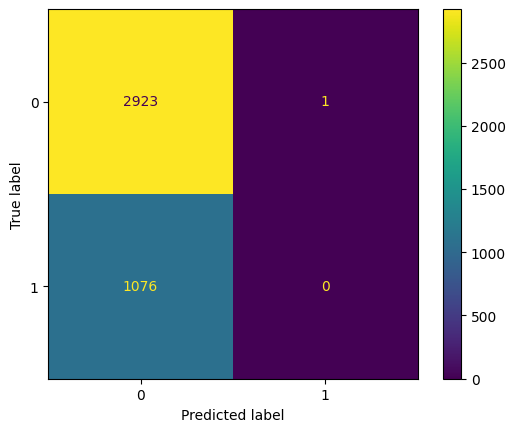

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
# Supposons que X_train, X_test, y_train, y_test sont déjà définis
# Étape 1 : Recherche des paramètres par défaut avec la première fonction
X_train, X_test, y_train, y_test = train_test_split(X_svd, train_new['cal_réponse_signalement'], test_size=0.8, random_state=42)

base_params, y_test, y_pred = try_find_best_model_defaut(X_train, X_test, y_train, y_test)

# Afficher les résultats de l'évaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report :\n", classification_report(y_test, y_pred))

# Afficher les paramètres du modèle
print("Model Parameters:", base_params)

# Calculer et afficher les scores de performance
accuracy = accuracy_score(y_test, y_pred)

# Remplacer 'Pris en compte' par l'étiquette positive (ajuste cette étiquette selon tes besoins)
precision = precision_score(y_test, y_pred, pos_label='Pris en compte')
recall = recall_score(y_test, y_pred, pos_label='Pris en compte')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)


# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()


In [ ]:
# Exemple d'utilisation
best_params_random, y_test, y_pred = try_find_best_model_random(X_train, X_test, y_train, y_test, base_params)

# Affichage des résultats
print("\nMeilleurs paramètres après recherche aléatoire :")
print(best_params_random)

# Évaluer les performances du meilleur modèle
print("\nAccuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report :\n", classification_report(y_test, y_pred))

# Calculer d'autres métriques
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # Assurez-vous de spécifier un average
recall = recall_score(y_test, y_pred, average='weighted')

print("\nAccuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
190 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
55 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils


Meilleurs paramètres après recherche aléatoire :
{'bootstrap': True, 'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 187}

Évaluation finale avec les meilleurs paramètres :
Accuracy : 0.70475

Classification Report :
                      precision    recall  f1-score   support

     Pris en compte       0.75      0.89      0.82      2924
Rejete (hors specs)       0.40      0.20      0.27      1076

           accuracy                           0.70      4000
          macro avg       0.58      0.54      0.54      4000
       weighted avg       0.66      0.70      0.67      4000


Meilleurs paramètres après recherche aléatoire :
{'bootstrap': True, 'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 187}

Accuracy : 0.70475

Classification Report :
                      precision    recall  f1-score   support

     Pris en compte       0.75      0.89      0.82      2924
Rejete (ho

In [ ]:
# Utiliser les meilleurs paramètres pour entraîner le modèle sur l'ensemble des données d'entraînement
print("\nEntraînement du modèle avec les meilleurs paramètres...")
best_rf = RandomForestClassifier(**best_params_random, random_state=42)
best_rf.fit(X_train, y_train)

# Prédire sur X_test_svd
y_pred_final = best_rf.predict(X_test_svd)

# Créer un DataFrame avec la colonne 'OGC_FID' de test_new et les prédictions
test_results = pd.DataFrame({
    'OGC_FID': test_new['OGC_FID'],  # Utiliser la colonne OGC_FID du jeu de données test
    'cal_réponse_signalement': y_pred_final
})

# Sauvegarder les résultats dans un fichier CSV sans l'index et avec un séparateur virgule
test_results.to_csv("soumission_randomforest_bestparams.csv", index=False, sep=',')

print("\nLe fichier CSV 'soumission_randomforest_bestparams.csv' a été généré avec succès sans index et avec séparateur virgule.")

# Évaluation des performances sur les données de test
print("\nÉvaluation du modèle final :")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report :\n", classification_report(y_test, y_pred))


Entraînement du modèle avec les meilleurs paramètres...

Le fichier CSV 'soumission_randomforest_bestparams.csv' a été généré avec succès sans index et avec séparateur virgule.

Évaluation du modèle final :
Accuracy : 0.70475

Classification Report :
                      precision    recall  f1-score   support

     Pris en compte       0.75      0.89      0.82      2924
Rejete (hors specs)       0.40      0.20      0.27      1076

           accuracy                           0.70      4000
          macro avg       0.58      0.54      0.54      4000
       weighted avg       0.66      0.70      0.67      4000



Modification des parmettre possible :

try_find_best_model_defaut

      poid des variable d'interrais class_weight

try_find_best_model_random :

    """param_grid = {
    'n_estimators': [+-100],
    'max_depth': [+-10],
    'min_samples_split': [+-5],
    'min_samples_leaf': [+-2],
    'max_features': [base_params],
    'bootstrap': [base_params]
    }"""

    poid des variable d'interrais class_weight

    Nombre d'itérations pour la recherche aléatoire "n_iter"
    Validation croisée "cv"
    Utiliser tous les cœurs du processeur "n_jobs"

# CONCLUSION

La régression logistique s'avère être le meilleur modèle dans ce contexte pour plusieurs raisons :

- Nature binaire du problème : La tâche consiste à classifier les annonces en deux catégories (pertinentes ou non pour l'IGN), ce qui correspond parfaitement au cas d'usage de la régression logistique
- Données textuelles sparse : La régression logistique gère efficacement les matrices creuses issues de la vectorisation du texte, contrairement à d'autres algorithmes qui peuvent avoir des difficultés avec ce type de données
- Interprétabilité : Les coefficients de la régression logistique permettent de comprendre l'importance relative de chaque terme dans la décision de classification
- Robustesse : La régression logistique est moins sensible au surapprentissage que des modèles plus complexes, particulièrement avec des données textuelles de taille modérée

De plus, la régression logistique offre un bon équilibre entre performance et complexité computationnelle, ce qui la rend particulièrement adaptée pour une application en production nécessitant des mises à jour régulières.